# magicbind — inline C++ in Jupyter

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/robomei/magicbind/blob/main/examples/notebook/magicbind_colab.ipynb)

Write C++ directly in a cell. magicbind compiles it and injects the module into the notebook.

In [1]:
%load_ext magicbind

## Simple function

Write C++ in the cell — the first argument after `%%magicbind` is the module name.

In [2]:
%%magicbind math_utils
#include <vector>
#include <optional>
#include <string>

double sum(const std::vector<double>& values)
{
    double s = 0;
    for (auto x : values) s += x;
    return s;
}

std::optional<double> mean(const std::vector<double>& values)
{
    if (values.empty()) return std::nullopt;
    return sum(values) / static_cast<double>(values.size());
}

double clamp(double value, double lo, double hi)
{
    return value < lo ? lo : value > hi ? hi : value;
}

[magicbind] generating bindings for math_utils...
[magicbind] 'math_utils' is ready


In [3]:
print(math_utils.sum([1.0, 2.0, 3.0, 4.0, 5.0]))
print(math_utils.mean([1.0, 2.0, 3.0]))
print(math_utils.mean([]))
print(math_utils.clamp(15.0, 0.0, 10.0))

15.0
2.0
None
10.0


## Struct

Structs are automatically bound — fields become Python attributes and a `__repr__` is generated.

In [4]:
%%magicbind geometry
#include <cmath>

struct Vec2 {
    float x;
    float y;
};

float dot(Vec2 a, Vec2 b)
{
    return a.x * b.x + a.y * b.y;
}

float length(Vec2 v)
{
    return std::sqrt(v.x * v.x + v.y * v.y);
}

Vec2 normalize(Vec2 v)
{
    float len = length(v);
    return {v.x / len, v.y / len};
}

[magicbind] generating bindings for geometry...
[magicbind] 'geometry' is ready


In [5]:
a = geometry.Vec2()
a.x = 3.0
a.y = 4.0
print(a)
print('length:', geometry.length(a))
print('normalized:', geometry.normalize(a))

Vec2(x=3.000000, y=4.000000)
length: 5.0
normalized: Vec2(x=0.600000, y=0.800000)


## Mandelbrot

Mandelbrot set computation.

In [6]:
%%magicbind mandelbrot
#include <vector>

std::vector<int> render(double x_min, double x_max,
                        double y_min, double y_max,
                        int width, int height, int max_iter)
{
    std::vector<int> result(width * height);
    double dx = (x_max - x_min) / width;
    double dy = (y_max - y_min) / height;
    for (int row = 0; row < height; ++row)
{
        double c_im = y_min + row * dy;
        for (int col = 0; col < width; ++col)
{
            double c_re = x_min + col * dx;
            double z_re = 0, z_im = 0;
            int iter = 0;
            while (z_re*z_re + z_im*z_im <= 4.0 && iter < max_iter)
{
                double tmp = z_re*z_re - z_im*z_im + c_re;
                z_im = 2.0*z_re*z_im + c_im;
                z_re = tmp;
                ++iter;
            }
            result[row * width + col] = iter;
        }
    }
    return result;
}

[magicbind] generating bindings for mandelbrot...
[magicbind] 'mandelbrot' is ready


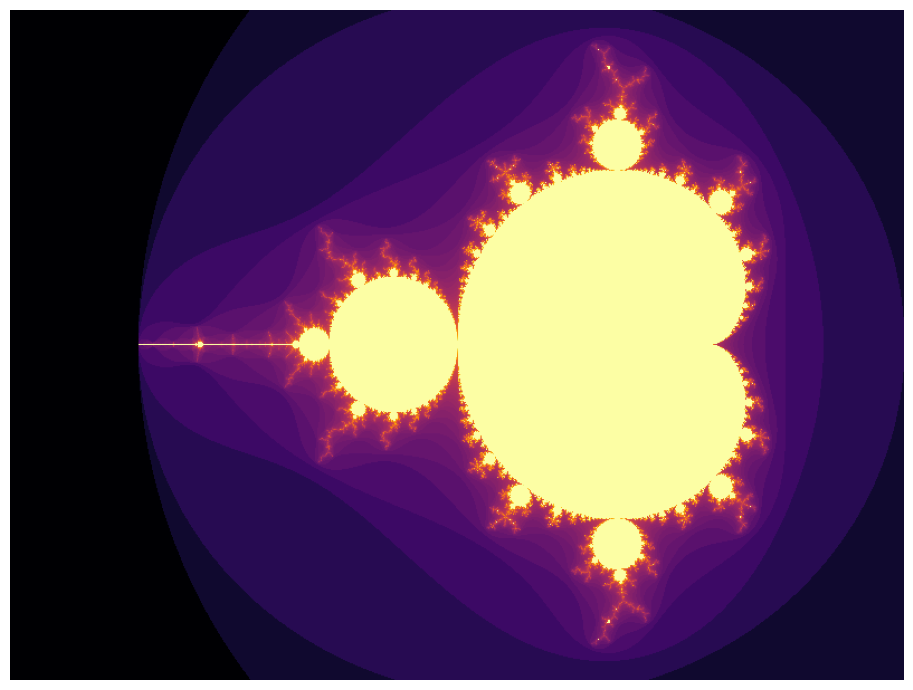

In [7]:
import numpy as np
import matplotlib.pyplot as plt

W, H, MAX_ITER = 800, 600, 256
result = mandelbrot.render(-2.5, 1.0, -1.25, 1.25, W, H, MAX_ITER)

img = np.array(result).reshape(H, W)
img = np.log1p(img) / np.log1p(MAX_ITER)

plt.figure(figsize=(10, 7))
plt.imshow(img, cmap='inferno', origin='lower')
plt.axis('off')
plt.tight_layout()
plt.show()

## OpenCV integration

magicbind ships built-in type casters for OpenCV types — `cv::Mat` maps to a numpy array, `cv::Point`, `cv::Rect`, `cv::Scalar` map to tuples.

In [8]:
%%magicbind image_ops --pkg opencv4
#include <opencv2/core.hpp>
#include <opencv2/imgproc.hpp>
#include <vector>

// Returns image dimensions as (width, height)
cv::Size image_size(const cv::Mat& image)
{
    return image.size();
}

// Converts BGR image to grayscale
cv::Mat to_grayscale(const cv::Mat& image)
{
    cv::Mat out;
    cv::cvtColor(image, out, cv::COLOR_BGR2GRAY);
    return out;
}

// Applies Gaussian blur
cv::Mat blur(const cv::Mat& image, int ksize)
{
    cv::Mat out;
    cv::GaussianBlur(image, out, cv::Size(ksize, ksize), 0);
    return out;
}

// Draws a filled rectangle onto the image
cv::Mat draw_rect(const cv::Mat& image, cv::Rect region, cv::Scalar color)
{
    cv::Mat out = image.clone();
    cv::rectangle(out, region, color, cv::FILLED);
    return out;
}

[magicbind] generating bindings for image_ops...
[magicbind] 'image_ops' is ready


size: (300, 200)


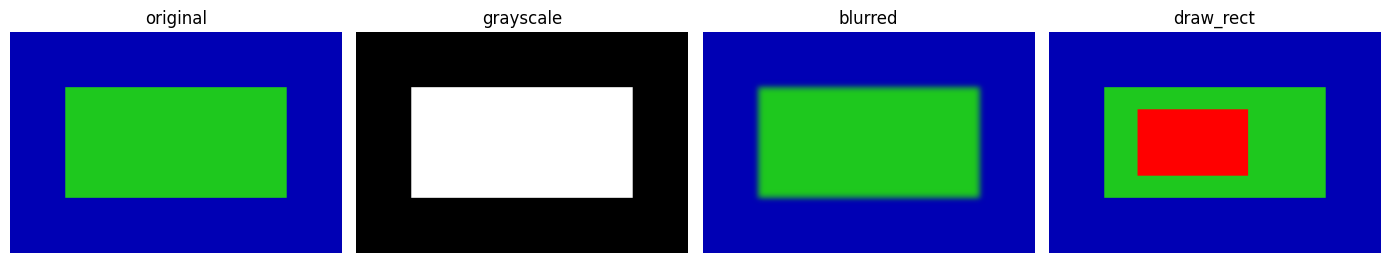

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# create a synthetic BGR test image
img = np.zeros((200, 300, 3), dtype=np.uint8)
img[:, :, 0] = 180   # blue channel
img[50:150, 50:250] = (30, 200, 30)   # green rectangle

print("size:", image_ops.image_size(img))

gray = image_ops.to_grayscale(img)
blurred = image_ops.blur(img, 15)
annotated = image_ops.draw_rect(img, (80, 70, 100, 60), (0, 0, 255))

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (title, data, cmap) in zip(axes, [
    ("original", img[:, :, ::-1], None),
    ("grayscale", gray, "gray"),
    ("blurred", blurred[:, :, ::-1], None),
    ("draw_rect", annotated[:, :, ::-1], None),
]):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()